In [4]:
import pandas as pd
from pathlib import Path

base_dir = Path(r"D:\Bussiness_plan\Multimodal_PM25")
data_dir = base_dir / "data" / "raw" / "DataSample"

aqi_2022_data = pd.read_csv(data_dir / "2022.csv")
aqi_2023_data = pd.read_csv(data_dir / "2023.csv")
aqi_2024_data = pd.read_csv(data_dir / "2024.csv")
aqi_2025_data = pd.read_csv(data_dir / "2025.csv")

print(aqi_2022_data.head())

            Local Time             UTC Time   City Country Code  \
0  2022-01-13 00:00:00  2022-01-12T17:00:00  Hanoi           VN   
1  2022-01-13 01:00:00  2022-01-12T18:00:00  Hanoi           VN   
2  2022-01-13 02:00:00  2022-01-12T19:00:00  Hanoi           VN   
3  2022-01-13 03:00:00  2022-01-12T20:00:00  Hanoi           VN   
4  2022-01-13 04:00:00  2022-01-12T21:00:00  Hanoi           VN   

           Timezone    AQI     CO   NO2    O3   PM10   PM25   SO2  Clouds  \
0  Asia/Ho_Chi_Minh  180.0  381.3  16.7  86.7  109.3  77.67  54.7     100   
1  Asia/Ho_Chi_Minh  181.0  389.8  17.0  87.0  111.0  79.00  59.0     100   
2  Asia/Ho_Chi_Minh  178.0  385.0  16.0  87.3  107.3  76.33  58.7      91   
3  Asia/Ho_Chi_Minh  174.0  380.1  15.0  87.7  103.7  73.67  58.3      83   
4  Asia/Ho_Chi_Minh  171.0  375.3  14.0  88.0  100.0  71.00  58.0      75   

   Precipitation  Pressure  Relative Humidity  Temperature  UV Index  \
0            0.0      1019                 93         17.0    

In [5]:
aqi_2022_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8472 entries, 0 to 8471
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Local Time         8472 non-null   object 
 1   UTC Time           8472 non-null   object 
 2   City               8472 non-null   object 
 3   Country Code       8472 non-null   object 
 4   Timezone           8472 non-null   object 
 5   AQI                8470 non-null   float64
 6   CO                 8398 non-null   float64
 7   NO2                8398 non-null   float64
 8   O3                 8398 non-null   float64
 9   PM10               8470 non-null   float64
 10  PM25               8470 non-null   float64
 11  SO2                8398 non-null   float64
 12  Clouds             8472 non-null   int64  
 13  Precipitation      8472 non-null   float64
 14  Pressure           8472 non-null   int64  
 15  Relative Humidity  8472 non-null   int64  
 16  Temperature        8472 

In [6]:
aqi_2022_data["Local Time"] = pd.to_datetime(aqi_2022_data["Local Time"])

In [7]:
aqi_2022_data.set_index("Local Time", inplace=True)
aqi_2022_data.head()

,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
Local Time,,,,,,,,,,,,,,,,,,
2022-01-13 00:00:00,2022-01-12T17:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,180.0,381.3,16.7,86.7,109.3,77.67,54.7,100,0.0,1019,93,17.0,0.0,1.22
2022-01-13 01:00:00,2022-01-12T18:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,181.0,389.8,17.0,87.0,111.0,79.00,59.0,100,0.0,1019,97,16.8,0.0,1.33
2022-01-13 02:00:00,2022-01-12T19:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,178.0,385.0,16.0,87.3,107.3,76.33,58.7,91,0.0,1019,97,16.4,0.0,1.44
2022-01-13 03:00:00,2022-01-12T20:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,174.0,380.1,15.0,87.7,103.7,73.67,58.3,83,0.0,1019,97,16.1,0.0,3.10
2022-01-13 04:00:00,2022-01-12T21:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,171.0,375.3,14.0,88.0,100.0,71.00,58.0,75,0.0,1018,97,15.7,0.0,1.66


In [8]:
# feature_selected = ["PM25", "Relative Humidity", "Temperature", "Wind Speed"]
feature_selected = ["Temperature"]
data = aqi_2022_data[feature_selected]
data.head()

,Temperature
Local Time,
2022-01-13 00:00:00,17.0
2022-01-13 01:00:00,16.8
2022-01-13 02:00:00,16.4
2022-01-13 03:00:00,16.1
2022-01-13 04:00:00,15.7


In [9]:
data.describe()

,Temperature
count,8472.000000
mean,24.737890
std,5.694465
min,8.500000
25%,20.900000
50%,25.600000
75%,28.700000
max,38.500000


In [10]:
data.isnull().sum()

Temperature    0
dtype: int64

In [11]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

# Assign values safely to avoid warnings
data.loc[:, 'Temperature'] = imputer.fit_transform(data[['Temperature']])


C:\Users\Admin\AppData\Local\Temp\ipykernel_22628\540322981.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[[17. ]
 [16.8]
 [16.4]
 ...
 [15.5]
 [15.3]
 [15.1]]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data.loc[:, 'Temperature'] = imputer.fit_transform(data[['Temperature']])


In [12]:
data.isnull().sum()

Temperature    0
dtype: int64

In [13]:
label = data["Temperature"].values.reshape(-1, 1)
label.shape

(8472, 1)

In [14]:
from sklearn.preprocessing import StandardScaler

sc_x = StandardScaler()
sc_y = StandardScaler()
data_standarded = sc_x.fit_transform(data)
label = sc_y.fit_transform(label)

In [15]:
label.shape

(8472, 1)

In [16]:
data_standarded.shape, label.shape

((8472, 1), (8472, 1))

In [17]:
data_standarded

array([[-1.35892414],
       [-1.39404804],
       [-1.46429583],
       ...,
       [-1.62235336],
       [-1.65747726],
       [-1.69260115]], shape=(8472, 1))

In [18]:
label

array([[-1.35892414],
       [-1.39404804],
       [-1.46429583],
       ...,
       [-1.62235336],
       [-1.65747726],
       [-1.69260115]], shape=(8472, 1))

In [19]:
import numpy as np

def create_window(X: np.array, y: np.array, window_size: int, predict_length: int):
    """
    Create (X_window, y_target) pairs for the time-series model.

    Args:
        X (np.array): input data with shape (n_samples, n_features)
        y (np.array): target labels with shape (n_samples,)
        window_size (int): length of the historical sequence
        predict_length (int): number of future time steps to predict

    Returns:
        X_out (np.array): shape (n_windows, window_size, n_features)
        y_out (np.array): shape (n_windows, predict_length)
    """
    X_out = []
    y_out = []
    
    for i in range(len(X) - window_size - predict_length + 1):
        X_out.append(X[i:i+window_size])
        y_out.append(y[i+window_size:i+window_size+predict_length])
    
    return np.array(X_out), np.array(y_out)


In [20]:
window_size = 24
predict_length = 24
X, y = create_window(data_standarded, label, window_size, predict_length)
X.shape, y.shape

((8425, 24, 1), (8425, 24, 1))

In [21]:
from sklearn.model_selection import train_test_split

x_train, x_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5)

len(x_train), len(y_train), len(x_val), len(y_val), len(x_test), len(y_test)

(5897, 5897, 1264, 1264, 1264, 1264)

In [22]:
x_train.shape, y_train.shape

((5897, 24, 1), (5897, 24, 1))

In [23]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, DepthwiseConv1D, LayerNormalization, Dropout, Dense, GRU, Add, ReLU
)
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model


def build_model(window_size, predict_length):
    inputs = Input(shape=(window_size, 1))

    # Block 1
    x = Conv1D(filters=128, kernel_size=1, padding='causal',
               kernel_initializer=HeNormal())(inputs)
    x = ReLU()(x)
    x = LayerNormalization()(x)
    residual = x
    x = DepthwiseConv1D(kernel_size=3, dilation_rate=1, padding='same')(x)
    x = ReLU()(x)
    x = LayerNormalization()(x)
    x = Dropout(0.2)(x)
    x = Add()([x, residual])   # Skip connection

    # Block 2
    x = Conv1D(filters=64, kernel_size=1, padding='causal',
               kernel_initializer=HeNormal())(x)
    x = ReLU()(x)
    x = LayerNormalization()(x)
    residual = x
    x = DepthwiseConv1D(kernel_size=3, dilation_rate=2, padding='same')(x)
    x = ReLU()(x)
    x = LayerNormalization()(x)
    x = Dropout(0.2)(x)
    x = Add()([x, residual])   # Skip connection

    # Block 3
    x = Conv1D(filters=32, kernel_size=1, padding='causal',
               kernel_initializer=HeNormal())(x)
    x = ReLU()(x)
    x = LayerNormalization()(x)
    residual = x
    x = DepthwiseConv1D(kernel_size=3, dilation_rate=4, padding='same')(x)
    x = ReLU()(x)
    x = LayerNormalization()(x)
    x = Dropout(0.2)(x)
    x = Add()([x, residual])

    # Block 4
    x = Conv1D(filters=16, kernel_size=1, padding='causal',
               kernel_initializer=HeNormal())(x)
    x = ReLU()(x)
    x = LayerNormalization()(x)
    residual = x
    x = DepthwiseConv1D(kernel_size=3, dilation_rate=8, padding='same')(x)
    x = ReLU()(x)
    x = LayerNormalization()(x)
    x = Dropout(0.2)(x)
    x = Add()([x, residual])

    # Block 5
    x = Conv1D(filters=8, kernel_size=1, padding='causal',
               kernel_initializer=HeNormal())(x)
    x = ReLU()(x)
    x = LayerNormalization()(x)
    residual = x
    x = DepthwiseConv1D(kernel_size=3, dilation_rate=16, padding='same')(x)
    x = ReLU()(x)
    x = LayerNormalization()(x)
    x = Dropout(0.2)(x)
    x = Add()([x, residual])

    # Dense + GRU head
    x = Dense(256, activation="relu")(x)
    x = GRU(predict_length)(x)
    x = Dropout(0.2)(x)
    outputs = Dense(predict_length)(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(loss='mse',
                  optimizer=Adam(learning_rate=0.001, amsgrad=True))
    return model


# Example model build
model = build_model(window_size, predict_length)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 128)   │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 24, 128)   │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 128)   │        256 │ re_lu[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv1d    │ (None, 24, 128)   │        512 │ layer_normalizat… │
│ (DepthwiseConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 24, 128)   │          0 │ depthwise_conv1d… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 128)   │        256 │ re_lu_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 128)   │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 128)   │          0 │ dropout[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 64)    │      8,256 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 24, 64)    │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ re_lu_2[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv1d_1  │ (None, 24, 64)    │        256 │ layer_normalizat… │
│ (DepthwiseConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 24, 64)    │          0 │ depthwise_conv1d… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ re_lu_3[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 64)    │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 64)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 24, 32)    │      2,080 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 24, 32)    │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 32)    │         64 │ re_lu_4[0][0]     │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 36,448 (142.38 KB)

 Trainable params: 36,448 (142.38 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=32,
    # callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)


Epoch 1/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.4523 - val_loss: 0.3003
Epoch 2/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.2927 - val_loss: 0.2313
Epoch 3/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.2348 - val_loss: 0.1686
Epoch 4/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.2139 - val_loss: 0.1644
Epoch 5/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1946 - val_loss: 0.1502
Epoch 6/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.1808 - val_loss: 0.1380
Epoch 7/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.1708 - val_loss: 0.1418
Epoch 8/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.1704 - val_loss: 0.1340
Epoch 9/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.1633 - val_loss: 0.1292
Epoch 10/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.1589 - val_loss: 0.1273
Epoch 11/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.1568 - val_loss: 0.1294
Epoch 12/50
185/185 ━━━━━━━━━━━━━━━━━━━━

In [25]:
model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=32,
    # callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)


Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1217 - val_loss: 0.0953
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1222 - val_loss: 0.0979
Epoch 3/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1209 - val_loss: 0.1081
Epoch 4/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.1197 - val_loss: 0.0951
Epoch 5/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.1234 - val_loss: 0.0928
Epoch 6/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1205 - val_loss: 0.0962
Epoch 7/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1192 - val_loss: 0.0947
Epoch 8/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1186 - val_loss: 0.0951
Epoch 9/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1178 - val_loss: 0.0924
Epoch 10/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1169 - val_loss: 0.0916
Epoch 11/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.1182 - val_loss: 0.0958
Epoch 12/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 

In [26]:
model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=32,
    # callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)


Epoch 1/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1131 - val_loss: 0.0880
Epoch 2/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.1127 - val_loss: 0.0915
Epoch 3/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1130 - val_loss: 0.0875
Epoch 4/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1124 - val_loss: 0.0893
Epoch 5/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.1129 - val_loss: 0.0856
Epoch 6/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.1132 - val_loss: 0.0891
Epoch 7/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1131 - val_loss: 0.0889
Epoch 8/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1109 - val_loss: 0.0851
Epoch 9/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1093 - val_loss: 0.0862
Epoch 10/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1113 - val_loss: 0.0853


In [27]:
model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=32,
    # callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)


Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1091 - val_loss: 0.0848
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.1076 - val_loss: 0.0872
Epoch 3/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.1091 - val_loss: 0.0874
Epoch 4/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.1103 - val_loss: 0.0845
Epoch 5/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.1087 - val_loss: 0.0829
Epoch 6/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.1078 - val_loss: 0.0826
Epoch 7/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.1071 - val_loss: 0.0825
Epoch 8/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.1084 - val_loss: 0.0811
Epoch 9/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1071 - val_loss: 0.0805
Epoch 10/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.1089 - val_loss: 0.0808
Epoch 11/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.1084 - val_loss: 0.0818
Epoch 12/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 

In [28]:
model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=200,
    batch_size=32,
    # callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)


Epoch 1/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1037 - val_loss: 0.0788
Epoch 2/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1028 - val_loss: 0.0782
Epoch 3/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1047 - val_loss: 0.0763
Epoch 4/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.1014 - val_loss: 0.0774
Epoch 5/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.1020 - val_loss: 0.0753
Epoch 6/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.1032 - val_loss: 0.0794
Epoch 7/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.1011 - val_loss: 0.0767
Epoch 8/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.1015 - val_loss: 0.0751
Epoch 9/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.1001 - val_loss: 0.0737
Epoch 10/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0989 - val_loss: 0.0763
Epoch 11/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.1021 - val_loss: 0.0760
Epoch 12/200
185/185 ━━━━━━━━━

In [29]:
model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=300,
    batch_size=32,
    # callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)


Epoch 1/300
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0687 - val_loss: 0.0443
Epoch 2/300
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0681 - val_loss: 0.0466
Epoch 3/300
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0703 - val_loss: 0.0446
Epoch 4/300
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0699 - val_loss: 0.0477
Epoch 5/300
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0732 - val_loss: 0.0472
Epoch 6/300
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0697 - val_loss: 0.0462
Epoch 7/300
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0696 - val_loss: 0.0453
Epoch 8/300
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0703 - val_loss: 0.0499
Epoch 9/300
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0704 - val_loss: 0.0468
Epoch 10/300
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0694 - val_loss: 0.0463
Epoch 11/300
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0679 - val_loss: 0.0471
Epoch 12/300
185/185 ━━━━━━━━━

In [30]:
model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=500,
    batch_size=32,
    # callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)


Epoch 1/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0558 - val_loss: 0.0334
Epoch 2/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0560 - val_loss: 0.0319
Epoch 3/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0560 - val_loss: 0.0387
Epoch 4/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0561 - val_loss: 0.0340
Epoch 5/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0540 - val_loss: 0.0331
Epoch 6/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0550 - val_loss: 0.0329
Epoch 7/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0548 - val_loss: 0.0324
Epoch 8/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0546 - val_loss: 0.0339
Epoch 9/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0551 - val_loss: 0.0309
Epoch 10/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0542 - val_loss: 0.0343
Epoch 11/500
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0567 - val_loss: 0.0339
Epoch 12/500
185/185 ━━━━━━━━━

In [31]:
x_test.shape

(1264, 24, 1)

In [32]:
y_pred = model.predict(x_test)  # y_pred.shape = (samples, predict_length)


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [33]:
y_true = y_test.squeeze()
y_true.shape

(1264, 24)

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Flatten arrays to compare the full prediction sequence
y_true = np.squeeze(y_test)


# Compute metrics
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")


MAE: 0.1179
RMSE: 0.1604
R2: 0.9744


In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Flatten arrays to compare the full prediction sequence
y_true = y_test.flatten()
y_pred_flat = y_pred.flatten()

# Compute metrics
mse = mean_squared_error(y_true, y_pred_flat)
mae = mean_absolute_error(y_true, y_pred_flat)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred_flat)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")


MAE: 0.1179
RMSE: 0.1604
R2: 0.9744


In [36]:
y_true.shape

(30336,)

In [37]:
# Convert back to the original scale
y_pred_inv = sc_y.inverse_transform(y_pred_flat.reshape(-1, 1))
y_true_inv = sc_y.inverse_transform(y_true.reshape(-1, 1))
mse = mean_squared_error(y_true_inv, y_pred_inv)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_inv, y_pred_inv)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

MAE: 0.6716
RMSE: 0.9132
R2: 0.9744


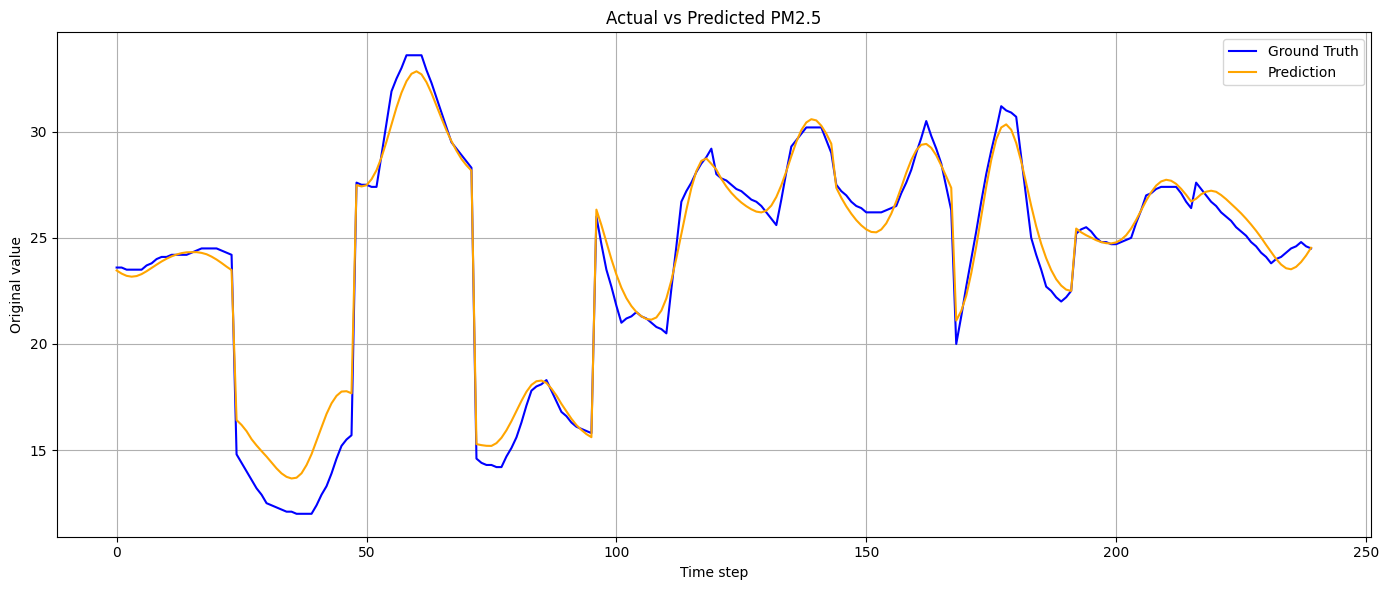

In [38]:
import matplotlib.pyplot as plt

# Plot line chart
plt.figure(figsize=(14, 6))
plt.plot(y_true_inv[:240], label='Ground Truth', color='blue')
plt.plot(y_pred_inv[:240], label='Prediction', color='orange')
plt.title('Actual vs Predicted PM2.5')
plt.xlabel('Time step')
plt.ylabel('Original value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [39]:
model.save("models/pm25.keras")

FileNotFoundError: [Errno 2] No such file or directory: 'models/pm25.keras'